In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
"""Constants"""

mu0 = 4 * np.pi * 1e-7
I = 10
R = 2

num_segments = 200

In [3]:
"""Create the circular loop"""

theta = np.linspace(0, 2*np.pi, num_segments, endpoint=False)

x_loop = R * np.cos(theta)
y_loop = R * np.sin(theta)
z_loop = np.zeros(num_segments)

dtheta = 2 * np.pi / num_segments

dl_x = -R * np.sin(theta) * dtheta
dl_y = R * np.cos(theta) * dtheta
dl_z = np.zeros(num_segments)

In [4]:
"""Create the XZ observation plane"""

x = np.linspace(-4, 4, 30)
z = np.linspace(-4, 4, 30)

X, Z = np.meshgrid(x, z)

Bx = np.zeros_like(X)
By = np.zeros_like(X)
Bz = np.zeros_like(X)

In [5]:
"""Apply the Biot-Savart Law"""

for i in range(num_segments):

    rx = X - x_loop[i]
    ry = -y_loop[i]
    rz = Z - z_loop[i]

    r = np.sqrt(rx**2 + ry**2 + rz**2)

    r[r < 1e-9] = 1e-9

    cross_x = dl_y[i] * rz - dl_z[i] * ry
    cross_y = dl_z[i] * rx - dl_x[i] * rz
    cross_z = dl_x[i] * ry - dl_y[i] * rx

    dBx = mu0 * I / (4*np.pi) * cross_x / r**3
    dBy = mu0 * I / (4*np.pi) * cross_y / r**3
    dBz = mu0 * I / (4*np.pi) * cross_z / r**3

    Bx += dBx
    By += dBy
    Bz += dBz

In [6]:
"""Calculate the magnetic field magnitude"""

B = np.sqrt(Bx**2 + By**2 + Bz**2)

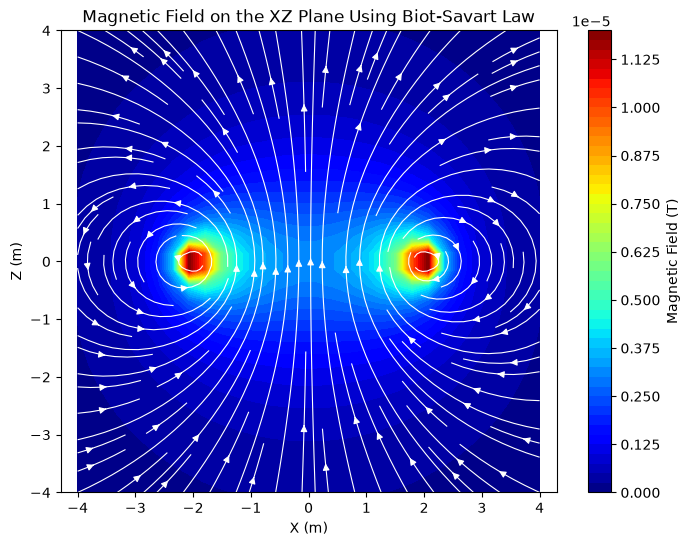

In [7]:
"""Plot the magnetic field on the XZ plane"""

plt.figure(figsize=(8,6))

plt.contourf(X, Z, B, levels=50, cmap="jet")

plt.colorbar(label="Magnetic Field (T)")

plt.streamplot(
    X,
    Z,
    Bx,
    Bz,
    color="white",
    density=1.2,
    linewidth=0.8
)

plt.xlabel("X (m)")
plt.ylabel("Z (m)")
plt.title("Magnetic Field on the XZ Plane Using Biot-Savart Law")

plt.axis("equal")

plt.show()

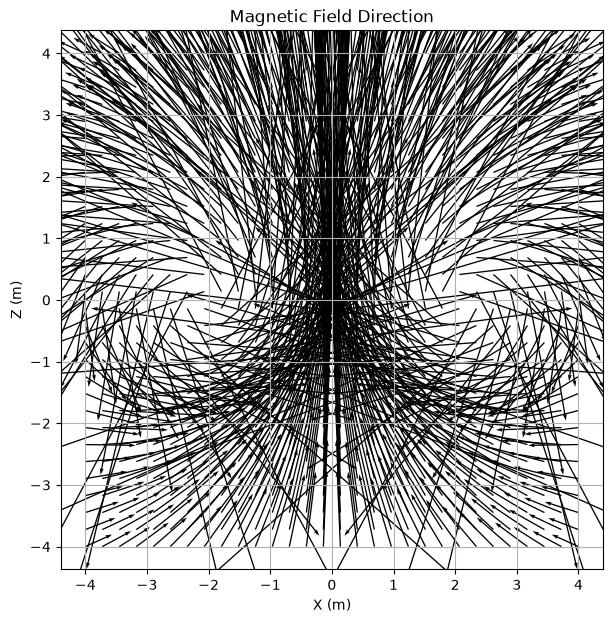

In [8]:
"""Plot only the field vectors"""

plt.figure(figsize=(7,7))

plt.quiver(
    X,
    Z,
    Bx,
    Bz,
    scale=2e-6
)

plt.xlabel("X (m)")
plt.ylabel("Z (m)")
plt.title("Magnetic Field Direction")

plt.axis("equal")

plt.grid(True)

plt.show()